**Kiểm tra kết nối các file dữ liệu của cuộc thi** 

In [4]:
import os

DATA_PATH = "../dataset"
files = os.listdir(DATA_PATH)
print(f"Tìm thấy {len(files)} files:")
for f in sorted(files):
    print(f"  📄 {f}")

Tìm thấy 2 files:
  📄 processed
  📄 raw


**Import các thư viện liên quan và tạo dictionary {file_name: DataFrame} (Bắt buộc)**

In [5]:
import pandas as pd
import numpy as np
import os

# ── Đường dẫn dataset trên Kaggle ──
DATA_PATH = "../dataset/raw"

# ── Danh sách 14 file ──
FILES = {
    # Master
    "products":           "products.csv",
    "customers":          "customers.csv",
    "promotions":         "promotions.csv",
    "geography":          "geography.csv",
    # Transaction
    "orders":             "orders.csv",
    "order_items":        "order_items.csv",
    "payments":           "payments.csv",
    "shipments":          "shipments.csv",
    "returns":            "returns.csv",
    "reviews":            "reviews.csv",
    # Analytical
    "sales_train":        "sales.csv",
    "sample_submission":  "sample_submission.csv",
    # Operational
    "inventory":          "inventory.csv",
    "web_traffic":        "web_traffic.csv",
}

# ── Load tất cả vào dictionary ──
dfs = {}
for name, filename in FILES.items():
    filepath = os.path.join(DATA_PATH, filename)
    dfs[name] = pd.read_csv(filepath, low_memory=False)
    print(f"{name:20s} → shape: {dfs[name].shape}")

products             → shape: (2412, 8)
customers            → shape: (121930, 7)
promotions           → shape: (50, 10)
geography            → shape: (39948, 4)
orders               → shape: (646945, 8)
order_items          → shape: (714669, 7)
payments             → shape: (646945, 4)
shipments            → shape: (566067, 4)
returns              → shape: (39939, 7)
reviews              → shape: (113551, 7)
sales_train          → shape: (3833, 3)
sample_submission    → shape: (548, 3)
inventory            → shape: (60247, 17)
web_traffic          → shape: (3652, 7)


**Kiểm tra shape, dtypes, null từng bảng dữ liệu** 

In [6]:
# ── Kiểm tra chi tiết từng bảng ──
for name, df in dfs.items():
    print(f"\n{'='*55}")
    print(f"📋 BẢNG: {name.upper()}")
    print(f"   Dòng: {df.shape[0]:,}  |  Cột: {df.shape[1]}")
    print(f"\n   Kiểu dữ liệu:")
    for col, dtype in df.dtypes.items():
        null_pct = df[col].isna().mean() * 100
        flag = " ⚠️ có null" if null_pct > 0 else ""
        print(f"     {col:30s} {str(dtype):10s} "
              f"(null: {null_pct:.1f}%){flag}")
    print(f"\n   3 dòng đầu:")
    display(df.head(3))


📋 BẢNG: PRODUCTS
   Dòng: 2,412  |  Cột: 8

   Kiểu dữ liệu:
     product_id                     int64      (null: 0.0%)
     product_name                   object     (null: 0.0%)
     category                       object     (null: 0.0%)
     segment                        object     (null: 0.0%)
     size                           object     (null: 0.0%)
     color                          object     (null: 0.0%)
     price                          float64    (null: 0.0%)
     cogs                           float64    (null: 0.0%)

   3 dòng đầu:


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278



📋 BẢNG: CUSTOMERS
   Dòng: 121,930  |  Cột: 7

   Kiểu dữ liệu:
     customer_id                    int64      (null: 0.0%)
     zip                            int64      (null: 0.0%)
     city                           object     (null: 0.0%)
     signup_date                    object     (null: 0.0%)
     gender                         object     (null: 0.0%)
     age_group                      object     (null: 0.0%)
     acquisition_channel            object     (null: 0.0%)

   3 dòng đầu:


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search



📋 BẢNG: PROMOTIONS
   Dòng: 50  |  Cột: 10

   Kiểu dữ liệu:
     promo_id                       object     (null: 0.0%)
     promo_name                     object     (null: 0.0%)
     promo_type                     object     (null: 0.0%)
     discount_value                 float64    (null: 0.0%)
     start_date                     object     (null: 0.0%)
     end_date                       object     (null: 0.0%)
     applicable_category            object     (null: 80.0%) ⚠️ có null
     promo_channel                  object     (null: 0.0%)
     stackable_flag                 int64      (null: 0.0%)
     min_order_value                int64      (null: 0.0%)

   3 dòng đầu:


...

,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12



📋 BẢNG: INVENTORY
   Dòng: 60,247  |  Cột: 17

   Kiểu dữ liệu:
     snapshot_date                  object     (null: 0.0%)
     product_id                     int64      (null: 0.0%)
     stock_on_hand                  int64      (null: 0.0%)
     units_received                 int64      (null: 0.0%)
     units_sold                     int64      (null: 0.0%)
     stockout_days                  int64      (null: 0.0%)
     days_of_supply                 float64    (null: 0.0%)
     fill_rate                      float64    (null: 0.0%)
     stockout_flag                  int64      (null: 0.0%)
     overstock_flag                 int64      (null: 0.0%)
     reorder_flag                   int64      (null: 0.0%)
     sell_through_rate              float64    (null: 0.0%)
     product_name                   object     (null: 0.0%)
     category                       object     (null: 0.0%)
     segment                        object     (null: 0.0%)
     year                          

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12



📋 BẢNG: WEB_TRAFFIC
   Dòng: 3,652  |  Cột: 7

   Kiểu dữ liệu:
     date                           object     (null: 0.0%)
     sessions                       int64      (null: 0.0%)
     unique_visitors                int64      (null: 0.0%)
     page_views                     int64      (null: 0.0%)
     bounce_rate                    float64    (null: 0.0%)
     avg_session_duration_sec       float64    (null: 0.0%)
     traffic_source                 object     (null: 0.0%)

   3 dòng đầu:


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct


**Kiểm tra Data Integrity (Foreign Keys)**

In [7]:
# ── Kiểm tra Data Integrity (Foreign Keys) ──

checks = [
    # (tên_kiểm_tra, bảng_con, cột_fk, bảng_cha, cột_pk)
    # kiểm tra các mối quan hệ (cardinality) theo đề thi
    ("payments → orders",     "payments",    "order_id",    "orders",    "order_id"),
    ("shipments → orders",    "shipments",   "order_id",    "orders",    "order_id"),
    ("returns → orders",    "returns",     "order_id",  "orders",  "order_id"),
    ("reviews → orders",         "reviews",     "order_id",    "orders",    "order_id"),
    ("order_items → promotions", "order_items", "promo_id",    "promotions","promo_id"),
    ("inventory → products",     "inventory",   "product_id",  "products",  "product_id"),
    # Còn lại
    ("customers → geography",    "customers",   "zip",         "geography", "zip"),
    ("orders → geography",       "orders",      "zip",         "geography", "zip"),
    ("orders → customers",    "orders",      "customer_id", "customers", "customer_id"),
    ("order_items → orders",  "order_items", "order_id",    "orders",    "order_id"),
    ("order_items → products",   "order_items", "product_id",  "products",  "product_id"),
    ("returns → products",    "returns",     "product_id",  "products",  "product_id"),
    ("reviews → products",       "reviews",     "product_id",  "products",  "product_id"),
    ("reviews → customers",      "reviews",     "customer_id", "customers", "customer_id"),
]

print("=" * 55)
print("KIỂM TRA FOREIGN KEY INTEGRITY")
print("=" * 55)

all_clean = True
for name, child, fk, parent, pk in checks:
    fk_vals  = set(dfs[child][fk].dropna())
    pk_vals  = set(dfs[parent][pk].dropna())
    orphans  = fk_vals - pk_vals
    
    if len(orphans) == 0:
        print(f"✅ {name:30s} → OK (0 orphans)")
    else:
        all_clean = False
        print(f"❌ {name:30s} → {len(orphans):,} orphan records!")
        print(f"   Ví dụ: {list(orphans)[:5]}")

print()
if all_clean:
    print("🎉 Tất cả FK đều hợp lệ — data integrity tốt!")
else:
    print("⚠️  Có vấn đề FK — cần điều tra thêm trước khi join!")

KIỂM TRA FOREIGN KEY INTEGRITY
✅ payments → orders              → OK (0 orphans)
✅ shipments → orders             → OK (0 orphans)
✅ returns → orders               → OK (0 orphans)
✅ reviews → orders               → OK (0 orphans)
✅ order_items → promotions       → OK (0 orphans)
✅ inventory → products           → OK (0 orphans)
✅ customers → geography          → OK (0 orphans)
✅ orders → geography             → OK (0 orphans)
✅ orders → customers             → OK (0 orphans)
✅ order_items → orders           → OK (0 orphans)
✅ order_items → products         → OK (0 orphans)
✅ returns → products             → OK (0 orphans)
✅ reviews → products             → OK (0 orphans)
✅ reviews → customers            → OK (0 orphans)

🎉 Tất cả FK đều hợp lệ — data integrity tốt!


**Import các thư viện liên quan và chuyển đổi kiểu dữ liệu thời gian (object -> datetime)**

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Convert Date sang datetime ──
dfs["sales_train"]["Date"] = pd.to_datetime(dfs["sales_train"]["Date"])
print("✅ Kiểu dữ liệu cột Date:", dfs["sales_train"]["Date"].dtype)
print(f"   Từ: {dfs['sales_train']['Date'].min().date()}")
print(f"   Đến: {dfs['sales_train']['Date'].max().date()}")
print(f"   Tổng số ngày: {dfs['sales_train']['Date'].nunique():,}")

✅ Kiểu dữ liệu cột Date: datetime64[ns]
   Từ: 2012-07-04
   Đến: 2022-12-31
   Tổng số ngày: 3,833


**Trực quan hóa nhanh một số biểu đồ doanh thu để thấy được trend, pattern, noise**

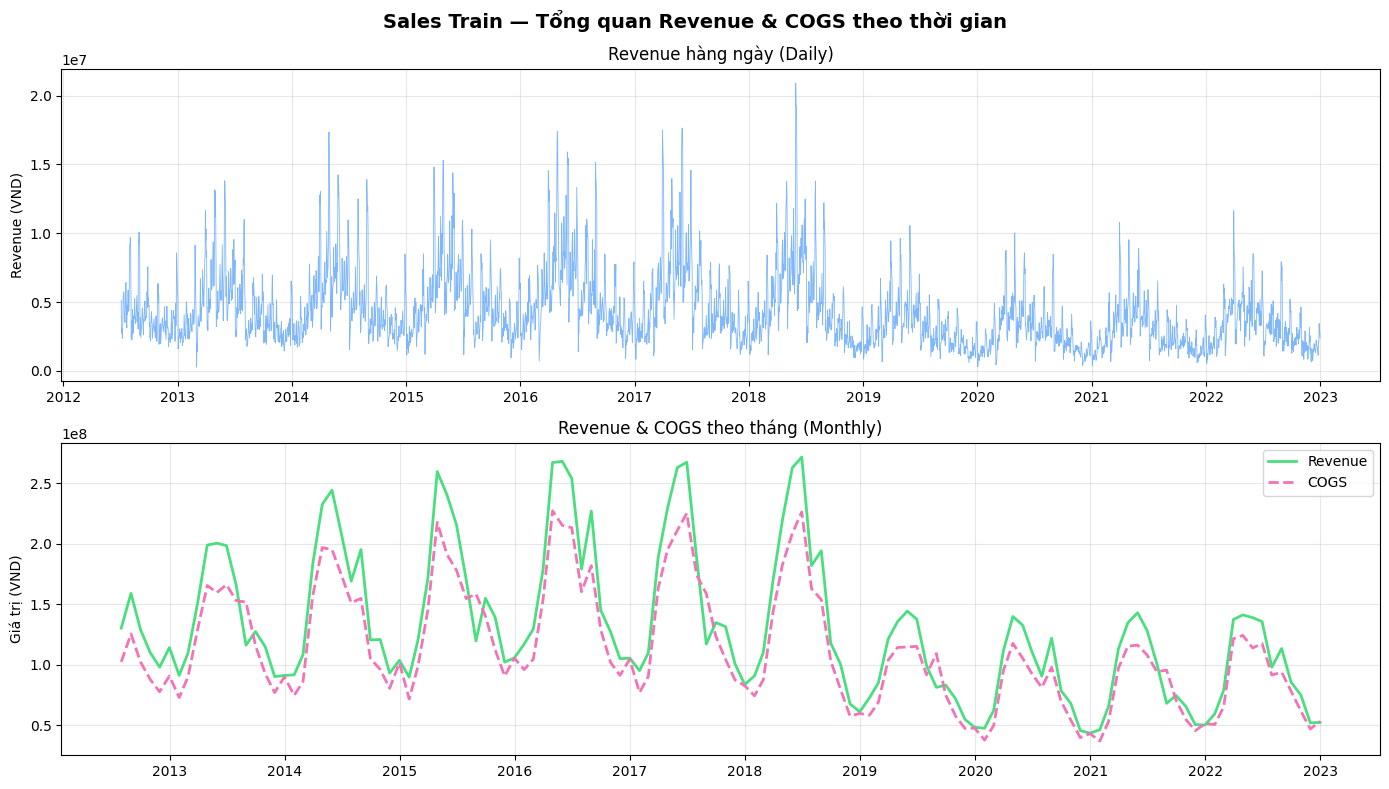

In [9]:
# ── Plot Revenue daily + monthly ──
sales = dfs["sales_train"].copy()
sales = sales.set_index("Date").sort_index()

# Gộp theo tháng
sales_monthly = sales.resample("ME").sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Sales Train — Tổng quan Revenue & COGS theo thời gian",
             fontsize=14, fontweight="bold")

# Plot 1: Daily Revenue
axes[0].plot(sales.index, sales["Revenue"],
             color="#60a5fa", linewidth=0.6, alpha=0.8)
axes[0].set_title("Revenue hàng ngày (Daily)")
axes[0].set_ylabel("Revenue (VND)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].grid(True, alpha=0.3)

# Plot 2: Monthly Revenue + COGS
axes[1].plot(sales_monthly.index, sales_monthly["Revenue"],
             color="#4ade80", linewidth=2, label="Revenue")
axes[1].plot(sales_monthly.index, sales_monthly["COGS"],
             color="#f472b6", linewidth=2, label="COGS", linestyle="--")
axes[1].set_title("Revenue & COGS theo tháng (Monthly)")
axes[1].set_ylabel("Giá trị (VND)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Thống kê mô tả nhanh ──
print("\n📊 THỐNG KÊ MÔ TẢ — sales_train.csv")
print("-" * 40)
print(sales[["Revenue", "COGS"]].describe().round(2))

# Gross Profit margin trung bình
sales["Gross_Profit"] = sales["Revenue"] - sales["COGS"]
sales["GP_Margin"] = (sales["Gross_Profit"] / sales["Revenue"]) * 100
print(f"\n💰 Gross Profit Margin trung bình: "
      f"{sales['GP_Margin'].mean():.1f}%")
print(f"📈 Tổng Revenue toàn bộ period: "
      f"{sales['Revenue'].sum():,.0f}")


📊 THỐNG KÊ MÔ TẢ — sales_train.csv
----------------------------------------
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67

💰 Gross Profit Margin trung bình: 12.5%
📈 Tổng Revenue toàn bộ period: 16,430,476,586


# ANGLE 1: Hiệu suất Doanh thu & Lợi nhuận theo thời gian

**A. TRỰC QUAN HÓA (VISUALIZATION)**

**1. Viz 1: Line chart Revenue + COGS + Gross Profit theo tháng**

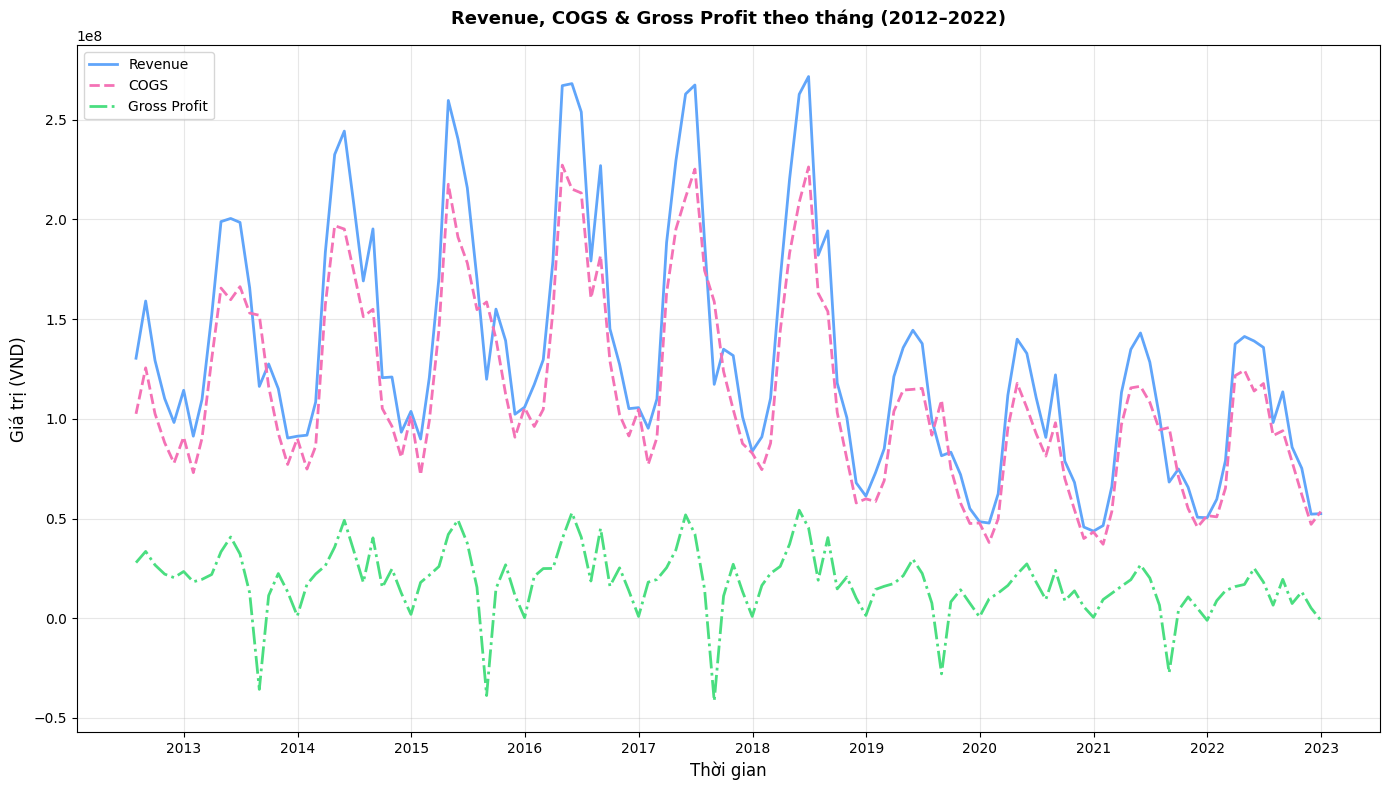

✅ Viz 1 saved


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Chuẩn bị data ──
sales = dfs["sales_train"].copy()
sales["Date"] = pd.to_datetime(sales["Date"])
sales = sales.set_index("Date").sort_index()

# Tính Gross Profit
sales["Gross_Profit"] = sales["Revenue"] - sales["COGS"]

# Gộp theo tháng
monthly = sales.resample("ME").sum()

# ── Vẽ biểu đồ ──
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(monthly.index, monthly["Revenue"],
        color="#60a5fa", linewidth=2, label="Revenue")
ax.plot(monthly.index, monthly["COGS"],
        color="#f472b6", linewidth=2, label="COGS", linestyle="--")
ax.plot(monthly.index, monthly["Gross_Profit"],
        color="#4ade80", linewidth=2, label="Gross Profit", linestyle="-.")

ax.set_title("Revenue, COGS & Gross Profit theo tháng (2012–2022)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Thời gian", fontsize=12)
ax.set_ylabel("Giá trị (VND)", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("a1_viz1_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 1 saved")

**2. Viz 2: Bar chart Revenue theo năm + YoY Growth %**

📊 Doanh thu theo năm:
           Revenue  Gross_Profit  YoY_Growth_%
Date                                          
2012  7.414977e+08  1.540358e+08           NaN
2013  1.657169e+09  1.911893e+08           NaN
2014  1.871846e+09  2.972384e+08         12.95
2015  1.889934e+09  2.244920e+08          0.97
2016  2.104641e+09  3.240813e+08         11.36
2017  1.911164e+09  2.167785e+08         -9.19
2018  1.850122e+09  3.079467e+08         -3.19
2019  1.136801e+09  1.315986e+08        -38.56
2020  1.054512e+09  1.684271e+08         -7.24
2021  1.043040e+09  1.019097e+08         -1.09
2022  1.169749e+09  1.493287e+08         12.15


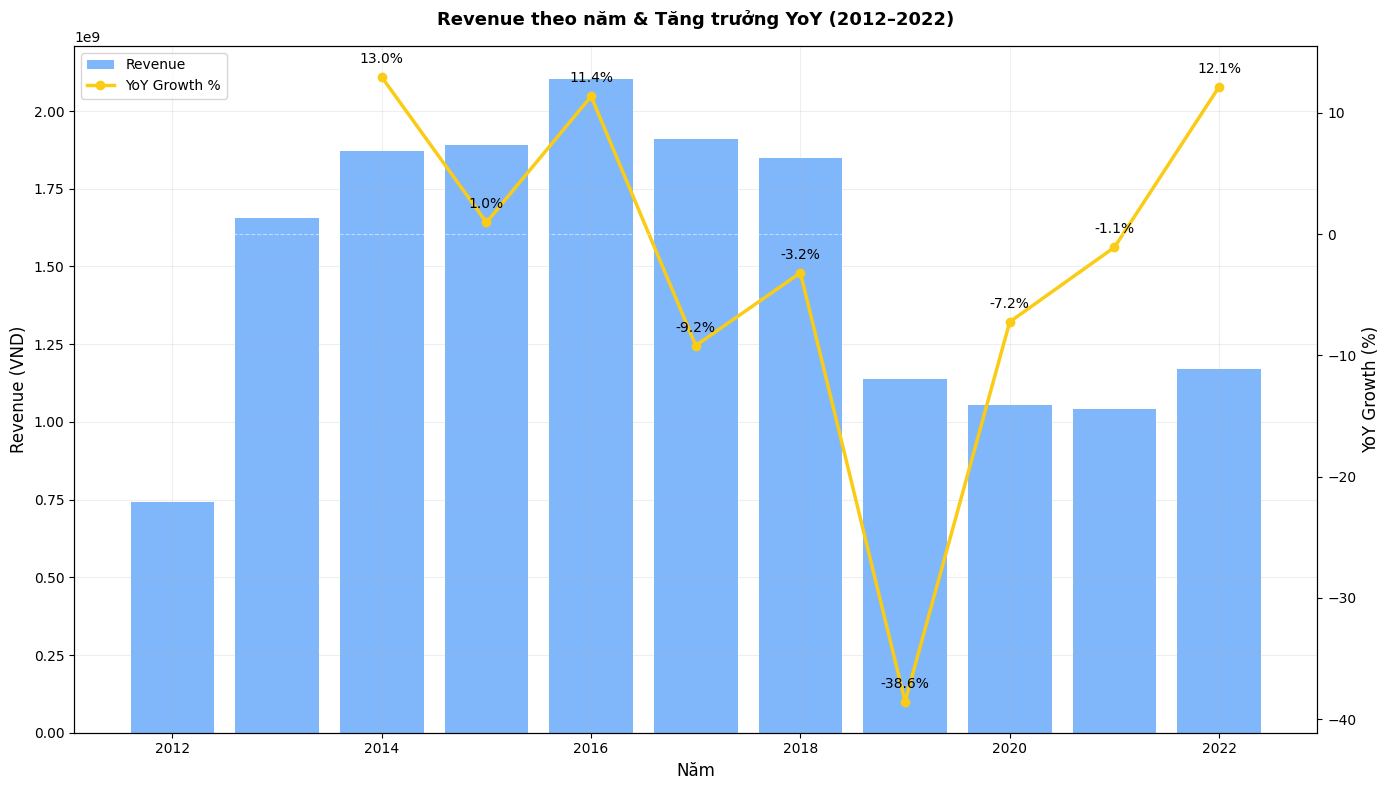

✅ Viz 2 saved


In [12]:
# ── Gộp theo năm ──
yearly = sales.resample("YE").sum()[["Revenue", "Gross_Profit"]]
yearly["YoY_Growth_%"] = yearly["Revenue"].pct_change() * 100
yearly.index = yearly.index.year  # Đổi index thành năm (số nguyên)
yearly.loc[2013, "YoY_Growth_%"] = np.nan  # Loại YoY 2013 mẫu số là 2012 không đầy đủ

print("📊 Doanh thu theo năm:")
print(yearly.round(2))

# ── Vẽ biểu đồ ──
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart Revenue
bars = ax1.bar(yearly.index, yearly["Revenue"],
               color="#60a5fa", alpha=0.8, label="Revenue")
ax1.set_xlabel("Năm",fontsize=12)
ax1.set_ylabel("Revenue (VND)", color="#000", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#000")

# Line chart YoY Growth % (trục y thứ 2)
ax2 = ax1.twinx()
ax2.plot(yearly.index[2:], yearly["YoY_Growth_%"][2:],
         color="#facc15", linewidth=2.5,
         marker="o", markersize=6, label="YoY Growth %")
ax2.axhline(y=0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax2.set_ylabel("YoY Growth (%)", color="#000", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#000")

# Thêm label % lên từng điểm
for year, val in zip(yearly.index[1:], yearly["YoY_Growth_%"][1:]):
    ax2.annotate(f"{val:.1f}%",
                 xy=(year, val),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=10, color="#000")

ax1.set_title("Revenue theo năm & Tăng trưởng YoY (2012–2022)",
              fontsize=13, fontweight="bold", pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("a1_viz2_yearly_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 2 saved")

**3. Viz 3: Heatmap Revenue theo tháng × năm**

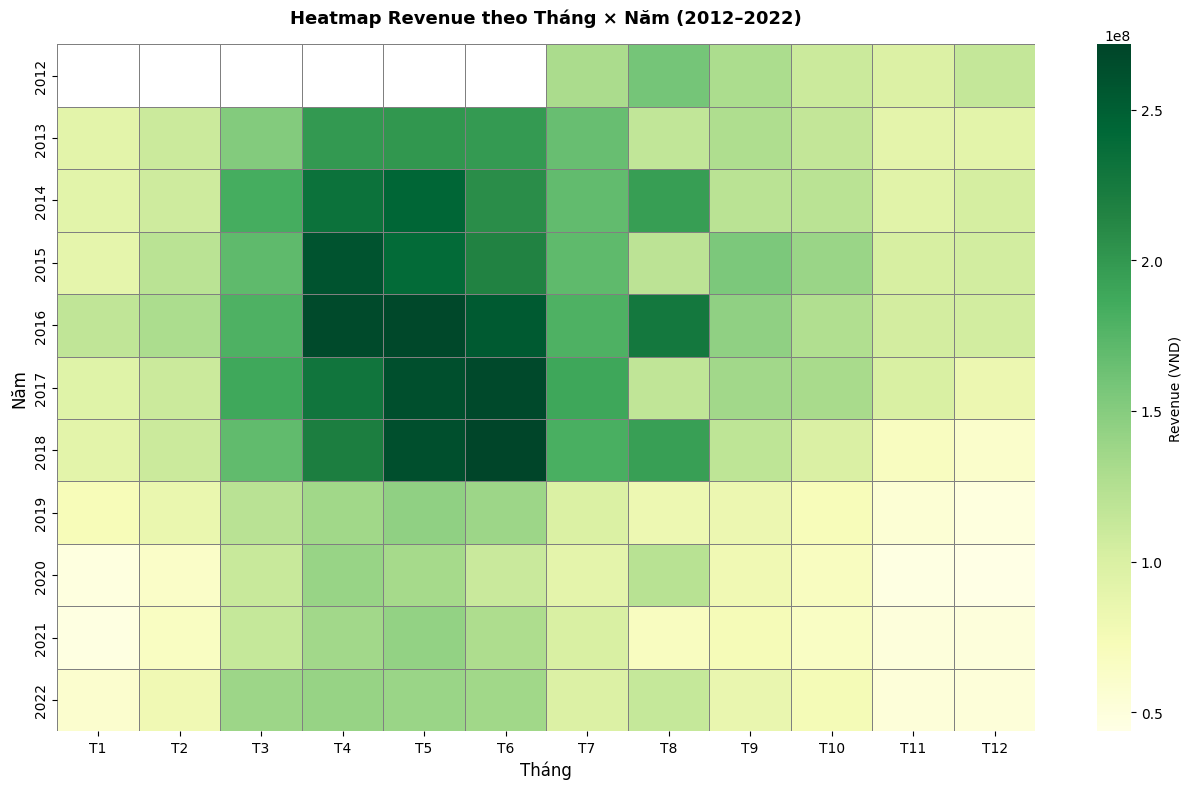

✅ Viz 3 saved


In [13]:
# ── Tạo pivot table: hàng = năm, cột = tháng ──
sales_heatmap = sales["Revenue"].resample("ME").sum()
heatmap_df = pd.DataFrame({
    "Year":  sales_heatmap.index.year,
    "Month": sales_heatmap.index.month,
    "Revenue": sales_heatmap.values
})

pivot = heatmap_df.pivot_table(
    index="Year", columns="Month", values="Revenue"
)
pivot.columns = ["T1","T2","T3","T4","T5","T6",
                 "T7","T8","T9","T10","T11","T12"]

# ── Vẽ heatmap ──
fig, ax = plt.subplots(figsize=(13, 8))

sns.heatmap(
    pivot,
    cmap="YlGn",
    fmt=".0f",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Revenue (VND)"},
    ax=ax
)

ax.set_title("Heatmap Revenue theo Tháng × Năm (2012–2022)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Tháng", fontsize=12)
ax.set_ylabel("Năm", fontsize=12)

plt.tight_layout()
plt.savefig("a1_viz3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 3 saved")

**B. PHÂN TÍCH DỮ LIỆU**

In [14]:
# ── Tổng doanh thu từng tháng của từng năm ──

sales_copy = dfs["sales_train"].copy()
sales_copy["Date"]  = pd.to_datetime(sales_copy["Date"])
sales_copy["Year"]  = sales_copy["Date"].dt.year
sales_copy["Month"] = sales_copy["Date"].dt.month

# Gộp theo năm + tháng
monthly_by_year = sales_copy.groupby(
    ["Year", "Month"]
)["Revenue"].sum().reset_index()

# Xoay thành pivot: hàng = năm, cột = tháng
pivot = monthly_by_year.pivot(
    index="Year", columns="Month", values="Revenue"
)
pivot.columns = [f"T{m:02d}" for m in pivot.columns]

# Thêm cột tổng năm
#pivot["TỔNG NĂM"] = pivot.sum(axis=1)

# In ra
print("=" * 100)
print("DOANH THU TỪNG THÁNG THEO NĂM (VND)")
print("=" * 100)
print(pivot.map(lambda x: f"{x:,.0f}" 
                     if pd.notna(x) else "N/A").to_string())

# In thêm tổng từng tháng (tất cả các năm)
print("\n" + "-" * 100)
monthly_total = pivot.sum()
print("TỔNG TẤT CẢ NĂM THEO THÁNG:")
for col, val in monthly_total.items():
    print(f"  {col}: {val:>15,.0f} VND")

DOANH THU TỪNG THÁNG THEO NĂM (VND)
              T01          T02          T03          T04          T05          T06          T07          T08          T09          T10          T11          T12
Year                                                                                                                                                            
2012          N/A          N/A          N/A          N/A          N/A          N/A  130,406,774  159,089,240  129,307,134  110,185,694   98,186,295  114,322,611
2013   91,308,677  109,783,138  151,834,657  198,926,932  200,500,109  198,517,629  165,745,354  116,271,756  127,534,148  115,089,837   90,371,312   91,285,868
2014   91,803,715  108,440,957  183,513,882  232,565,641  244,309,542  208,133,786  169,157,948  195,265,820  120,621,539  120,982,778   93,293,577  103,756,698
2015   89,880,637  120,682,457  170,940,315  259,694,425  240,384,686  215,836,392  170,237,048  119,854,987  155,030,677  139,230,979  102,311,827  105,849,39

**1. PHÂN TÍCH DESCRIPTIVE**

In [15]:
# ── DESCRIPTIVE: Thống kê tổng hợp ──
sales = dfs["sales_train"].copy()
sales["Date"] = pd.to_datetime(sales["Date"])
sales = sales.set_index("Date").sort_index()
sales["Gross_Profit"] = sales["Revenue"] - sales["COGS"]
sales["GP_Margin"]    = sales["Gross_Profit"] / sales["Revenue"] * 100

monthly = sales.resample("ME").sum()
yearly  = sales.resample("YE").sum()
yearly.index = yearly.index.year

print("=" * 55)
print("DESCRIPTIVE — Thống kê tổng hợp")
print("=" * 55)
print(f"\n📌 Tổng Revenue toàn kỳ (07/2012-2022): "
      f"{sales['Revenue'].sum():>15,.0f} VND")
print(f"📌 Tổng Gross Profit toàn kỳ:         "
      f"{sales['Gross_Profit'].sum():>15,.0f} VND")
print(f"📌 GP Margin trung bình:               "
      f"{sales['GP_Margin'].mean():>14.1f}%")
print(f"📌 Revenue trung bình/tháng:           "
      f"{monthly['Revenue'].mean():>15,.0f} VND")
print(f"📌 Revenue cao nhất/tháng:             "
      f"{monthly['Revenue'].max():>15,.0f} VND")
print(f"📌 Revenue thấp nhất/tháng:            "
      f"{monthly['Revenue'].min():>15,.0f} VND")

print(f"\n📊 Revenue theo từng năm:")
for year, row in yearly.iterrows():
    print(f"   {year}: {row['Revenue']:>12,.0f} VND  "
          f"| GP Margin: {row['Gross_Profit']/row['Revenue']*100:.1f}%")

DESCRIPTIVE — Thống kê tổng hợp

📌 Tổng Revenue toàn kỳ (07/2012-2022):  16,430,476,586 VND
📌 Tổng Gross Profit toàn kỳ:           2,267,026,066 VND
📌 GP Margin trung bình:                         12.5%
📌 Revenue trung bình/tháng:               130,400,608 VND
📌 Revenue cao nhất/tháng:                 271,674,172 VND
📌 Revenue thấp nhất/tháng:                 43,671,564 VND

📊 Revenue theo từng năm:
   2012:  741,497,748 VND  | GP Margin: 20.8%
   2013: 1,657,169,417 VND  | GP Margin: 11.5%
   2014: 1,871,845,883 VND  | GP Margin: 15.9%
   2015: 1,889,933,827 VND  | GP Margin: 11.9%
   2016: 2,104,640,678 VND  | GP Margin: 15.4%
   2017: 1,911,164,325 VND  | GP Margin: 11.3%
   2018: 1,850,122,456 VND  | GP Margin: 16.6%
   2019: 1,136,801,442 VND  | GP Margin: 11.6%
   2020: 1,054,512,159 VND  | GP Margin: 16.0%
   2021: 1,043,039,820 VND  | GP Margin: 9.8%
   2022: 1,169,748,832 VND  | GP Margin: 12.8%


**2. PHÂN TÍCH DIAGNOSTIC**

In [16]:
# ── DIAGNOSTIC: Phân tích nguyên nhân ──
print("=" * 55)
print("DIAGNOSTIC — Phân tích nguyên nhân")
print("=" * 55)

yearly_full = sales.resample("YE").sum()
yearly_full.index = yearly_full.index.year

# Loại năm 2012
yearly = yearly_full[yearly_full.index != 2012].copy()
yearly["Gross_Profit"] = yearly["Revenue"] - yearly["COGS"]
yearly["GP_Margin_%"]  = yearly["Gross_Profit"] / yearly["Revenue"] * 100

# Tính YoY — nhưng loại 2013 vì mẫu số là 2012 không đầy đủ
yearly["YoY_Growth_%"] = yearly["Revenue"].pct_change() * 100
yearly.loc[2013, "YoY_Growth_%"] = np.nan  # Loại YoY 2013

print(f"\n📉 YoY Growth Rate theo năm:")
for year, row in yearly.iterrows():
    if pd.notna(row["YoY_Growth_%"]):
        sign  = "📈" if row["YoY_Growth_%"] > 0 else "📉"
        print(f"   {sign} {year}: {row['YoY_Growth_%']:>+.1f}%")

# Giai đoạn tăng trưởng vs suy giảm
peak_year    = yearly["Revenue"].idxmax()
trough_year  = yearly["Revenue"].idxmin()
peak_rev     = yearly["Revenue"].max()
trough_rev   = yearly["Revenue"].min()
decline_pct  = (trough_rev - peak_rev) / peak_rev * 100

print(f"\n📌 Năm đỉnh cao nhất : {peak_year} "
      f"({peak_rev:,.0f} VND)")
print(f"📌 Năm thấp nhất     : {trough_year} "
      f"({trough_rev:,.0f} VND)")
print("\t⚠️ Lưu ý: Loại bỏ năm 2012 vì chỉ có dữ liệu doanh thu nửa cuối năm")
print(f"📌 Mức sụt giảm từ đỉnh đến đáy: {decline_pct:.1f}%")

# Phân tích seasonality — tháng nào peak?
sales["Month"] = sales.index.month
monthly_avg = sales.groupby("Month")["Revenue"].mean()
total_avg   = monthly_avg.mean()

print(f"\n📅 Doanh thu trung bình theo tháng:")
for m, val in monthly_avg.items():
    ratio = val / total_avg
    bar   = "█" * int(ratio * 10)
    tag   = " ← PEAK" if m in [4, 5, 6] else \
            " ← LOW"  if m in [10, 11, 12, 1, 2] else ""
    print(f"   T{m:02d}: {val:,.0f}  "
          f"({ratio:.2f}x avg) {bar}{tag}")

# Peak season chiếm bao nhiêu % doanh thu?
peak_months = sales[sales["Month"].isin([4, 5, 6])]
peak_pct    = peak_months["Revenue"].sum() / sales["Revenue"].sum() * 100
print(f"\n📌 T4-T6 chiếm {peak_pct:.1f}% tổng doanh thu cả năm")

DIAGNOSTIC — Phân tích nguyên nhân

📉 YoY Growth Rate theo năm:
   📈 2014: +13.0%
   📈 2015: +1.0%
   📈 2016: +11.4%
   📉 2017: -9.2%
   📉 2018: -3.2%
   📉 2019: -38.6%
   📉 2020: -7.2%
   📉 2021: -1.1%
   📈 2022: +12.1%

📌 Năm đỉnh cao nhất : 2016 (2,104,640,678 VND)
📌 Năm thấp nhất     : 2021 (1,043,039,820 VND)
	⚠️ Lưu ý: Loại bỏ năm 2012 vì chỉ có dữ liệu doanh thu nửa cuối năm
📌 Mức sụt giảm từ đỉnh đến đáy: -50.4%

📅 Doanh thu trung bình theo tháng:
   T01: 2,591,155  (0.60x avg) █████ ← LOW
   T02: 3,480,801  (0.81x avg) ████████ ← LOW
   T03: 4,928,185  (1.14x avg) ███████████
   T04: 6,532,952  (1.51x avg) ███████████████ ← PEAK
   T05: 6,575,416  (1.52x avg) ███████████████ ← PEAK
   T06: 6,427,109  (1.49x avg) ██████████████ ← PEAK
   T07: 4,659,789  (1.08x avg) ██████████
   T08: 4,441,193  (1.03x avg) ██████████
   T09: 3,797,826  (0.88x avg) ████████
   T10: 3,302,725  (0.76x avg) ███████ ← LOW
   T11: 2,611,295  (0.60x avg) ██████ ← LOW
   T12: 2,524,350  (0.58x avg) ███

**Điều tra nguyên nhân sụt giảm doanh thu nửa cuối năm 2018**

3 giả thuyết cần kiểm tra:

* Giả thuyết A: Số lượng đơn hàng giảm?
              → Kiểm tra orders.csv

* Giả thuyết B: Giá trị trung bình mỗi đơn giảm?
              → Kiểm tra order_items.csv

* Giả thuyết C: Tỷ lệ huỷ đơn tăng?
              → Kiểm tra order_status trong orders.csv

So sánh cùng kỳ: Q3-Q4/2017 vs Q3-Q4/2018 — không so sánh với Q1-Q2 vì có seasonality

In [17]:
orders = dfs["orders"].copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["year"]    = orders["order_date"].dt.year
orders["quarter"] = orders["order_date"].dt.quarter
orders["month"]   = orders["order_date"].dt.month

order_items = dfs["order_items"].copy()

print("=" * 60)
print("DIAGNOSTIC — Điều tra sụt giảm doanh thu cuối 2018")
print("=" * 60)

DIAGNOSTIC — Điều tra sụt giảm doanh thu cuối 2018


In [18]:
# ── Giả thuyết A: Số lượng đơn hàng có giảm không? ──
print("\n📋 GIẢ THUYẾT A: Số lượng đơn hàng")
print("-" * 45)

# Đếm số đơn theo quý, từ 2016-2019
order_count = orders[orders["year"].isin([2016, 2017, 2018, 2019])] \
    .groupby(["year", "quarter"])["order_id"].count() \
    .reset_index()
order_count.columns = ["Năm", "Quý", "Số đơn"]

pivot_orders = order_count.pivot(
    index="Quý", columns="Năm", values="Số đơn"
)
print(pivot_orders.to_string())

# Tính % thay đổi Q3, Q4: 2017 → 2018
for q in [3, 4]:
    val_2017 = pivot_orders.loc[q, 2017]
    val_2018 = pivot_orders.loc[q, 2018]
    chg = (val_2018 - val_2017) / val_2017 * 100
    print(f"\nQ{q}/2017 vs Q{q}/2018: "
          f"{val_2017:,.0f} → {val_2018:,.0f} "
          f"({chg:+.1f}%)")


📋 GIẢ THUYẾT A: Số lượng đơn hàng
---------------------------------------------
Năm   2016   2017   2018   2019
Quý                            
1    15990  14476  13485   9260
2    29986  28250  28912  13990
3    20951  19735  18091  11201
4    15320  13549   9022   7150

Q3/2017 vs Q3/2018: 19,735 → 18,091 (-8.3%)

Q4/2017 vs Q4/2018: 13,549 → 9,022 (-33.4%)


In [19]:
# ── Giả thuyết B: Giá trị trung bình mỗi đơn có giảm không? ──
print("\n\n📋 GIẢ THUYẾT B: Giá trị trung bình mỗi đơn (AOV)")
print("-" * 45)

# Join order_items với orders để lấy ngày
items_with_date = order_items.merge(
    orders[["order_id", "order_date", "year", "quarter"]],
    on="order_id", how="left"
)

# Tính revenue mỗi đơn = sum(unit_price * quantity)
items_with_date["line_revenue"] = (
    items_with_date["unit_price"] * items_with_date["quantity"]
)
order_revenue = items_with_date.groupby(
    ["order_id", "year", "quarter"]
)["line_revenue"].sum().reset_index()
order_revenue.columns = ["order_id", "Năm", "Quý", "AOV"]

# AOV trung bình theo quý
aov_quarterly = order_revenue[
    order_revenue["Năm"].isin([2016, 2017, 2018, 2019])
].groupby(["Năm", "Quý"])["AOV"].mean().reset_index()

pivot_aov = aov_quarterly.pivot(
    index="Quý", columns="Năm", values="AOV"
)
print(pivot_aov.round(0).to_string())

for q in [3, 4]:
    val_2017 = pivot_aov.loc[q, 2017]
    val_2018 = pivot_aov.loc[q, 2018]
    chg = (val_2018 - val_2017) / val_2017 * 100
    print(f"\nAOV Q{q}/2017 vs Q{q}/2018: "
          f"{val_2017:,.0f} → {val_2018:,.0f} "
          f"({chg:+.1f}%)")



📋 GIẢ THUYẾT B: Giá trị trung bình mỗi đơn (AOV)
---------------------------------------------
Năm     2016     2017     2018     2019
Quý                                    
1    26645.0  27192.0  27540.0  30154.0
2    26318.0  26898.0  26103.0  29872.0
3    26315.0  22358.0  27324.0  23585.0
4    22068.0  23354.0  25467.0  24545.0

AOV Q3/2017 vs Q3/2018: 22,358 → 27,324 (+22.2%)

AOV Q4/2017 vs Q4/2018: 23,354 → 25,467 (+9.0%)


In [20]:
# ── Giả thuyết C: Tỷ lệ huỷ đơn có tăng không? ──
print("\n\n📋 GIẢ THUYẾT C: Tỷ lệ huỷ đơn (Cancellation Rate)")
print("-" * 45)

cancel_rate = orders[
    orders["year"].isin([2016, 2017, 2018, 2019])
].groupby(["year", "quarter"]).apply(
    lambda x: (x["order_status"] == "cancelled").sum() / len(x) * 100, include_groups=False
).reset_index()
cancel_rate.columns = ["Năm", "Quý", "Cancel Rate %"]

pivot_cancel = cancel_rate.pivot(
    index="Quý", columns="Năm", values="Cancel Rate %"
)
print(pivot_cancel.round(2).to_string())

for q in [3, 4]:
    val_2017 = pivot_cancel.loc[q, 2017]
    val_2018 = pivot_cancel.loc[q, 2018]
    chg = val_2018 - val_2017
    print(f"\nCancel Rate Q{q}/2017 vs Q{q}/2018: "
          f"{val_2017:.1f}% → {val_2018:.1f}% "
          f"({chg:+.1f} pp)")



📋 GIẢ THUYẾT C: Tỷ lệ huỷ đơn (Cancellation Rate)
---------------------------------------------
Năm  2016  2017  2018  2019
Quý                        
1    8.95  8.84  9.45  9.49
2    9.28  9.09  9.29  9.36
3    9.16  9.42  9.29  9.23
4    8.79  8.85  9.38  8.92

Cancel Rate Q3/2017 vs Q3/2018: 9.4% → 9.3% (-0.1 pp)

Cancel Rate Q4/2017 vs Q4/2018: 8.8% → 9.4% (+0.5 pp)


In [21]:
# ── Tổng kết Diagnostic ──
print("=" * 60)
print("KẾT LUẬN DIAGNOSTIC — Nguyên nhân sụt giảm cuối 2018")
print("=" * 60)
print(f"""
✅ NGUYÊN NHÂN CHÍNH: Sụt giảm số lượng đơn hàng

   Q3/2018 vs Q3/2017: 18,091 vs 19,735 đơn (-8.3%)
   Q4/2018 vs Q4/2017:  9,022 vs 13,549 đơn (-33.4%)

❌ KHÔNG PHẢI do giá trị đơn hàng giảm:
   AOV Q3/2018 tăng +22.2% | AOV Q4/2018 tăng +9.0%
   → Khách còn lại vẫn chi tiêu nhiều hơn

❌ KHÔNG PHẢI do tỷ lệ huỷ đơn tăng:
   Cancel rate chỉ thay đổi 0.1-0.5 pp — không đáng kể

🔎 GỢI Ý NGUYÊN NHÂN SÂU HƠN:
   Vấn đề nằm ở acquisition/retention khách hàng.
   Sẽ được phân tích chi tiết tại Angle 2 & Angle 7.
""")

KẾT LUẬN DIAGNOSTIC — Nguyên nhân sụt giảm cuối 2018

✅ NGUYÊN NHÂN CHÍNH: Sụt giảm số lượng đơn hàng

   Q3/2018 vs Q3/2017: 18,091 vs 19,735 đơn (-8.3%)
   Q4/2018 vs Q4/2017:  9,022 vs 13,549 đơn (-33.4%)

❌ KHÔNG PHẢI do giá trị đơn hàng giảm:
   AOV Q3/2018 tăng +22.2% | AOV Q4/2018 tăng +9.0%
   → Khách còn lại vẫn chi tiêu nhiều hơn

❌ KHÔNG PHẢI do tỷ lệ huỷ đơn tăng:
   Cancel rate chỉ thay đổi 0.1-0.5 pp — không đáng kể

🔎 GỢI Ý NGUYÊN NHÂN SÂU HƠN:
   Vấn đề nằm ở acquisition/retention khách hàng.
   Sẽ được phân tích chi tiết tại Angle 2 & Angle 7.



**3. PHÂN TÍCH PREDICTIVE**

In [22]:
# ── PREDICTIVE: Dự báo xu hướng ──
print("=" * 55)
print("PREDICTIVE — Dự báo xu hướng 2023")
print("=" * 55)

# Tính revenue trung bình T4-T6 của 3 năm gần nhất (2020-2022)
recent = sales[sales.index.year.isin([2020, 2021, 2022])]
recent_peak = recent[recent["Month"].isin([4, 5, 6])]
avg_peak_recent = recent_peak.groupby(
    [recent_peak.index.year, "Month"]
)["Revenue"].sum().groupby(level=0).sum().mean()

# Tính CAGR giai đoạn phục hồi 2021-2022
rev_2021 = yearly.loc[2021, "Revenue"]
rev_2022 = yearly.loc[2022, "Revenue"]
cagr_recovery = (rev_2022 / rev_2021 - 1) * 100

# Dự báo đơn giản 2023
forecast_2023 = rev_2022 * (1 + cagr_recovery / 100)

print(f"\n📌 Tốc độ phục hồi 2021→2022: +{cagr_recovery:.1f}%")
print(f"📌 Dự báo Revenue 2023 (giữ nguyên tốc độ phục hồi): "
      f"{forecast_2023:,.0f} VND")
print(f"📌 Dự báo doanh thu peak T4-T6/2023: "
      f"{avg_peak_recent * (1 + cagr_recovery/100):,.0f} VND")
print(f"\n⚠️  Lưu ý: Dự báo này dựa trên trend tuyến tính đơn giản.")
print(f"    Mô hình chính xác hơn sẽ được thực hiện ở Phần 3.")

PREDICTIVE — Dự báo xu hướng 2023

📌 Tốc độ phục hồi 2021→2022: +12.1%
📌 Dự báo Revenue 2023 (giữ nguyên tốc độ phục hồi): 1,311,850,519 VND
📌 Dự báo doanh thu peak T4-T6/2023: 450,794,958 VND

⚠️  Lưu ý: Dự báo này dựa trên trend tuyến tính đơn giản.
    Mô hình chính xác hơn sẽ được thực hiện ở Phần 3.


**4. PHÂN TÍCH PRESCRIPTIVE**

In [23]:
# ── PRESCRIPTIVE: Đề xuất hành động ──
print("=" * 55)
print("PRESCRIPTIVE — Đề xuất chiến lược")
print("=" * 55)

low_months  = sales[sales["Month"].isin([10, 11, 12, 1, 2])]
low_pct     = low_months["Revenue"].sum() / sales["Revenue"].sum() * 100
gp_margin   = sales["GP_Margin"].mean()

print(f"""
📋 DỰA TRÊN SỐ LIỆU PHÂN TÍCH:

1. TẬP TRUNG NGUỒN LỰC VÀO PEAK SEASON (T4-T6)
   → T4-T6 chiếm {peak_pct:.1f}% doanh thu — phân bổ tối thiểu
     60% ngân sách marketing vào T2-T3 để chuẩn bị hàng tồn kho
     và chiến dịch quảng cáo trước mùa cao điểm.

2. KÍCH CẦU MÙA THẤP ĐIỂM (T10-T2)
   → T10-T2 chỉ chiếm {low_pct:.1f}% doanh thu — cần chiến dịch
     khuyến mãi đặc biệt (flash sale, bundle) để kéo doanh thu
     lên ít nhất 15% trong giai đoạn này.

3. CẢI THIỆN GROSS PROFIT MARGIN
   → GP Margin hiện tại {gp_margin:.1f}% — xem xét tăng giá bán
     từ 3-5% ở nhóm sản phẩm Premium trong peak season khi
     demand cao, elasticity thấp.

4. PHỤC HỒI SAU COVID
   → Tốc độ phục hồi 2021→2022 là +{cagr_recovery:.1f}% — cần
     duy trì momentum bằng cách mở rộng thêm kênh bán online
     và đầu tư vào acquisition khách hàng mới trong 2023.
""")

PRESCRIPTIVE — Đề xuất chiến lược

📋 DỰA TRÊN SỐ LIỆU PHÂN TÍCH:

1. TẬP TRUNG NGUỒN LỰC VÀO PEAK SEASON (T4-T6)
   → T4-T6 chiếm 36.1% doanh thu — phân bổ tối thiểu
     60% ngân sách marketing vào T2-T3 để chuẩn bị hàng tồn kho
     và chiến dịch quảng cáo trước mùa cao điểm.

2. KÍCH CẦU MÙA THẤP ĐIỂM (T10-T2)
   → T10-T2 chỉ chiếm 28.2% doanh thu — cần chiến dịch
     khuyến mãi đặc biệt (flash sale, bundle) để kéo doanh thu
     lên ít nhất 15% trong giai đoạn này.

3. CẢI THIỆN GROSS PROFIT MARGIN
   → GP Margin hiện tại 12.5% — xem xét tăng giá bán
     từ 3-5% ở nhóm sản phẩm Premium trong peak season khi
     demand cao, elasticity thấp.

4. PHỤC HỒI SAU COVID
   → Tốc độ phục hồi 2021→2022 là +12.1% — cần
     duy trì momentum bằng cách mở rộng thêm kênh bán online
     và đầu tư vào acquisition khách hàng mới trong 2023.



In [24]:
# ── Tính các con số Prescriptive từ data ──

print("=" * 60)
print("PRESCRIPTIVE — Tính toán cơ sở đề xuất từ data")
print("=" * 60)

# ── Cơ sở 1: Peak season chiếm bao nhiêu % doanh thu? ──
sales["Month"] = sales.index.month
peak_rev  = sales[sales["Month"].isin([4,5,6])]["Revenue"].sum()
low_rev   = sales[sales["Month"].isin([10,11,12,1,2])]["Revenue"].sum()
total_rev = sales["Revenue"].sum()

peak_pct = peak_rev / total_rev * 100
low_pct  = low_rev  / total_rev * 100
mid_pct  = 100 - peak_pct - low_pct

print(f"\n📊 PHÂN BỔ DOANH THU THEO MÙA:")
print(f"   Peak season (T4-T6) : {peak_pct:.1f}% tổng doanh thu")
print(f"   Low season (T10-T2) : {low_pct:.1f}% tổng doanh thu")
print(f"   Mid season (T3,T7-T9): {mid_pct:.1f}% tổng doanh thu")

# ── Cơ sở 2: Chênh lệch doanh thu peak vs low ──
monthly_avg_peak = sales[
    sales["Month"].isin([4,5,6])
]["Revenue"].mean()
monthly_avg_low  = sales[
    sales["Month"].isin([10,11,12,1,2])
]["Revenue"].mean()
ratio_peak_low   = monthly_avg_peak / monthly_avg_low

print(f"\n📊 CHÊNH LỆCH PEAK vs LOW:")
print(f"   Doanh thu TB tháng peak : {monthly_avg_peak:,.0f} VND")
print(f"   Doanh thu TB tháng low  : {monthly_avg_low:,.0f} VND")
print(f"   Peak cao hơn low        : {ratio_peak_low:.1f}x")

# ── Cơ sở 3: GP Margin theo mùa ──
gp_margin_peak = sales[
    sales["Month"].isin([4,5,6])
]["GP_Margin"].mean()
gp_margin_low  = sales[
    sales["Month"].isin([10,11,12,1,2])
]["GP_Margin"].mean()
gp_margin_all  = sales["GP_Margin"].mean()

print(f"\n📊 GP MARGIN THEO MÙA:")
print(f"   GP Margin trung bình toàn kỳ : {gp_margin_all:.1f}%")
print(f"   GP Margin peak season (T4-T6): {gp_margin_peak:.1f}%")
print(f"   GP Margin low season (T10-T2): {gp_margin_low:.1f}%")

# ── Cơ sở 4: Tiềm năng kích cầu low season ──
# Nếu low season tăng thêm X% thì doanh thu tăng bao nhiêu?
uplift_scenarios = [10, 15, 20]
print(f"\n📊 TIỀM NĂNG TĂNG DOANH THU NẾU CẢI THIỆN LOW SEASON:")
for pct in uplift_scenarios:
    uplift = low_rev * pct / 100
    total_uplift_pct = uplift / total_rev * 100
    print(f"   Nếu low season tăng {pct}% "
          f"→ tổng doanh thu tăng thêm "
          f"{uplift:,.0f} VND "
          f"(+{total_uplift_pct:.1f}%)")

# ── Cơ sở 5: Tác động của việc giảm số đơn Q4/2018 ──
orders_lost_q4 = 13549 - 9022  # Số đơn bị mất Q4/2018
aov_q4_2018    = 25467          # AOV Q4/2018
revenue_lost   = orders_lost_q4 * aov_q4_2018

print(f"\n📊 THIỆT HẠI DO MẤT KHÁCH Q4/2018:")
print(f"   Số đơn hàng bị mất  : {orders_lost_q4:,} đơn")
print(f"   AOV trung bình       : {aov_q4_2018:,} VND")
print(f"   Doanh thu bị mất     : {revenue_lost:,.0f} VND")

PRESCRIPTIVE — Tính toán cơ sở đề xuất từ data

📊 PHÂN BỔ DOANH THU THEO MÙA:
   Peak season (T4-T6) : 36.1% tổng doanh thu
   Low season (T10-T2) : 28.2% tổng doanh thu
   Mid season (T3,T7-T9): 35.7% tổng doanh thu

📊 CHÊNH LỆCH PEAK vs LOW:
   Doanh thu TB tháng peak : 6,512,524 VND
   Doanh thu TB tháng low  : 2,888,780 VND
   Peak cao hơn low        : 2.3x

📊 GP MARGIN THEO MÙA:
   GP Margin trung bình toàn kỳ : 12.5%
   GP Margin peak season (T4-T6): 17.0%
   GP Margin low season (T10-T2): 14.4%

📊 TIỀM NĂNG TĂNG DOANH THU NẾU CẢI THIỆN LOW SEASON:
   Nếu low season tăng 10% → tổng doanh thu tăng thêm 463,360,362 VND (+2.8%)
   Nếu low season tăng 15% → tổng doanh thu tăng thêm 695,040,543 VND (+4.2%)
   Nếu low season tăng 20% → tổng doanh thu tăng thêm 926,720,725 VND (+5.6%)

📊 THIỆT HẠI DO MẤT KHÁCH Q4/2018:
   Số đơn hàng bị mất  : 4,527 đơn
   AOV trung bình       : 25,467 VND
   Doanh thu bị mất     : 115,289,109 VND


In [25]:
# ── Prescriptive hoàn chỉnh ──
print("\n" + "=" * 60)
print("PRESCRIPTIVE — Đề xuất hành động (có cơ sở từ data)")
print("=" * 60)

print(f"""
1. TỐI ƯU PHÂN BỔ NGÂN SÁCH MARKETING THEO MÙA
   Cơ sở: T4-T6 chiếm {peak_pct:.1f}% doanh thu, cao hơn
   tháng low season {ratio_peak_low:.1f}x.
   Đề xuất: Phân bổ ngân sách marketing tương ứng với
   tỷ trọng doanh thu — tập trung {peak_pct:.0f}% ngân sách
   vào T2-T3 để chuẩn bị cho peak season T4-T6.

2. KÍCH CẦU MÙA THẤP ĐIỂM (T10-T2)
   Cơ sở: Low season chỉ chiếm {low_pct:.1f}% doanh thu.
   Nếu tăng được 15% doanh thu low season →
   tổng doanh thu năm tăng thêm {low_rev*15/100:,.0f} VND
   (+{low_rev*15/100/total_rev*100:.1f}% tổng doanh thu).
   Đề xuất: Triển khai flash sale + bundle sản phẩm
   trong T11-T12 để kích cầu cuối năm.

3. BẢO VỆ GP MARGIN TRONG PEAK SEASON
   Cơ sở: GP Margin peak ({gp_margin_peak:.1f}%) cao hơn
   low season ({gp_margin_low:.1f}%).
   Đề xuất: Hạn chế discount sâu trong T4-T6 vì demand
   tự nhiên đã cao — giữ nguyên giá để tối đa hoá margin.

4. KHÔI PHỤC ACQUISITION KHÁCH HÀNG
   Cơ sở: Q4/2018 mất {orders_lost_q4:,} đơn hàng so với
   Q4/2017, tương đương {revenue_lost:,.0f} VND doanh thu.
   Đề xuất: Ưu tiên đầu tư vào kênh acquisition mới
   (phân tích chi tiết kênh hiệu quả nhất tại Angle 2
   & Angle 7).
""")


PRESCRIPTIVE — Đề xuất hành động (có cơ sở từ data)

1. TỐI ƯU PHÂN BỔ NGÂN SÁCH MARKETING THEO MÙA
   Cơ sở: T4-T6 chiếm 36.1% doanh thu, cao hơn
   tháng low season 2.3x.
   Đề xuất: Phân bổ ngân sách marketing tương ứng với
   tỷ trọng doanh thu — tập trung 36% ngân sách
   vào T2-T3 để chuẩn bị cho peak season T4-T6.

2. KÍCH CẦU MÙA THẤP ĐIỂM (T10-T2)
   Cơ sở: Low season chỉ chiếm 28.2% doanh thu.
   Nếu tăng được 15% doanh thu low season →
   tổng doanh thu năm tăng thêm 695,040,543 VND
   (+4.2% tổng doanh thu).
   Đề xuất: Triển khai flash sale + bundle sản phẩm
   trong T11-T12 để kích cầu cuối năm.

3. BẢO VỆ GP MARGIN TRONG PEAK SEASON
   Cơ sở: GP Margin peak (17.0%) cao hơn
   low season (14.4%).
   Đề xuất: Hạn chế discount sâu trong T4-T6 vì demand
   tự nhiên đã cao — giữ nguyên giá để tối đa hoá margin.

4. KHÔI PHỤC ACQUISITION KHÁCH HÀNG
   Cơ sở: Q4/2018 mất 4,527 đơn hàng so với
   Q4/2017, tương đương 115,289,109 VND doanh thu.
   Đề xuất: Ưu tiên đầu tư vào kên

# ANGLE 7: Phân tích Cohort & Customer Retention

In [26]:
# ── Angle 7: Cohort & Retention Analysis ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Chuẩn bị data ──
orders = dfs["orders"].copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Chỉ lấy đơn hàng đã hoàn thành (không lấy cancelled)
orders_valid = orders[
    orders["order_status"] != "cancelled"
].copy()

# Tạo cột tháng (Period)
orders_valid["order_month"] = (
    orders_valid["order_date"].dt.to_period("M")
)

# Tìm tháng mua đầu tiên của mỗi khách hàng
orders_valid["cohort_month"] = (
    orders_valid.groupby("customer_id")["order_month"]
    .transform("min")
)

# Tính cohort index = số tháng kể từ lần mua đầu
orders_valid["cohort_index"] = (
    orders_valid["order_month"] -
    orders_valid["cohort_month"]
).apply(lambda x: x.n)

print("✅ Data cohort đã chuẩn bị xong")
print(f"   Tổng đơn hàng hợp lệ : {len(orders_valid):,}")
print(f"   Tổng khách hàng      : {orders_valid['customer_id'].nunique():,}")
print(f"   Khoảng cohort index  : {orders_valid['cohort_index'].min()} → "
      f"{orders_valid['cohort_index'].max()}")

✅ Data cohort đã chuẩn bị xong
   Tổng đơn hàng hợp lệ : 587,483
   Tổng khách hàng      : 88,123
   Khoảng cohort index  : 0 → 125


**1. Viz 1: Heatmap Cohort Retention**

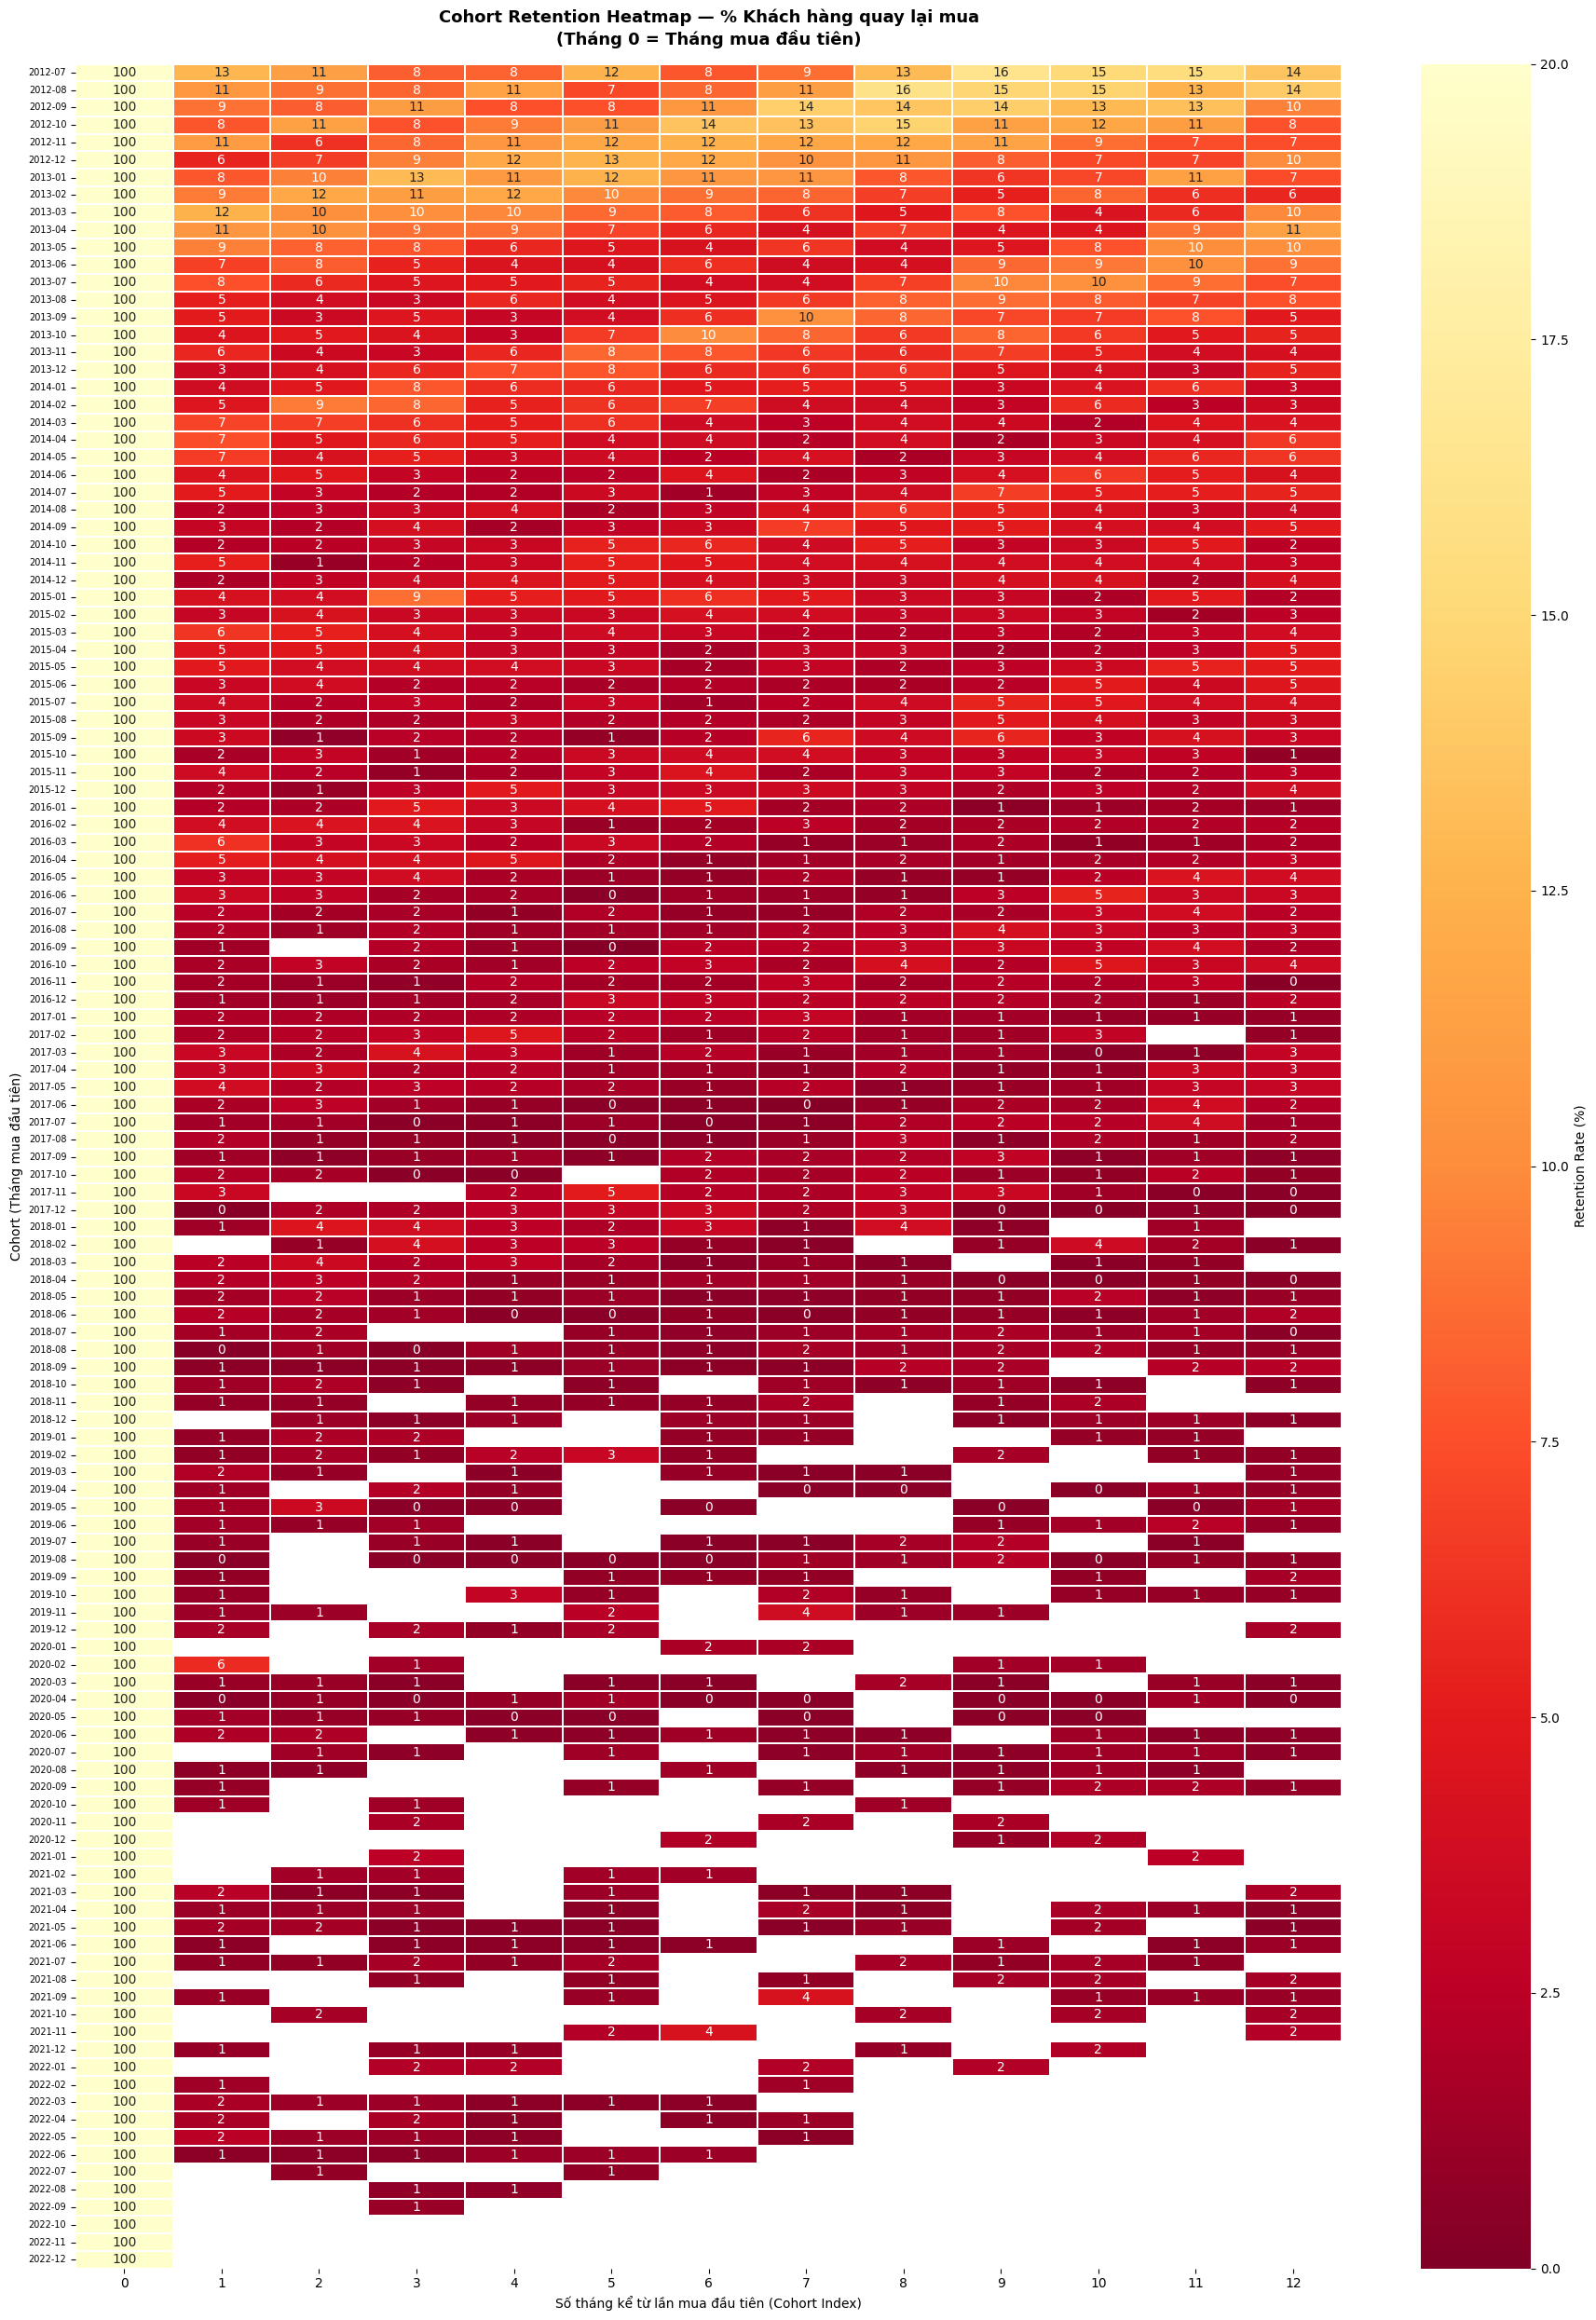

✅ Viz 7.1 saved


In [27]:
# ── Tạo cohort table ──
cohort_data = orders_valid.groupby(
    ["cohort_month", "cohort_index"]
)["customer_id"].nunique().reset_index()

cohort_pivot = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

# Tính retention rate (%) so với cohort size (tháng 0)
cohort_size   = cohort_pivot.iloc[:, 0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100

# Chỉ lấy 13 tháng đầu (0-12) để heatmap gọn
retention_12 = retention_pct.iloc[:, :13]

# ── Vẽ heatmap ──
fig, ax = plt.subplots(figsize=(18, 25))

sns.heatmap(
    retention_12,
    annot=True, fmt=".0f",
    cmap="YlOrRd_r",
    linewidths=0.3,
    linecolor="white",
    vmin=0, vmax=20,
    cbar_kws={"label": "Retention Rate (%)"},
    ax=ax
)

ax.set_title(
    "Cohort Retention Heatmap — % Khách hàng quay lại mua\n"
    "(Tháng 0 = Tháng mua đầu tiên)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Số tháng kể từ lần mua đầu tiên (Cohort Index)")
ax.set_ylabel("Cohort (Tháng mua đầu tiên)")
ax.set_yticklabels(
    [str(p) for p in retention_12.index],
    rotation=0, fontsize=7
)

plt.tight_layout()
plt.savefig("viz7_1_cohort_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 7.1 saved")

**2. Viz 2: Retention Curve so sánh theo năm**

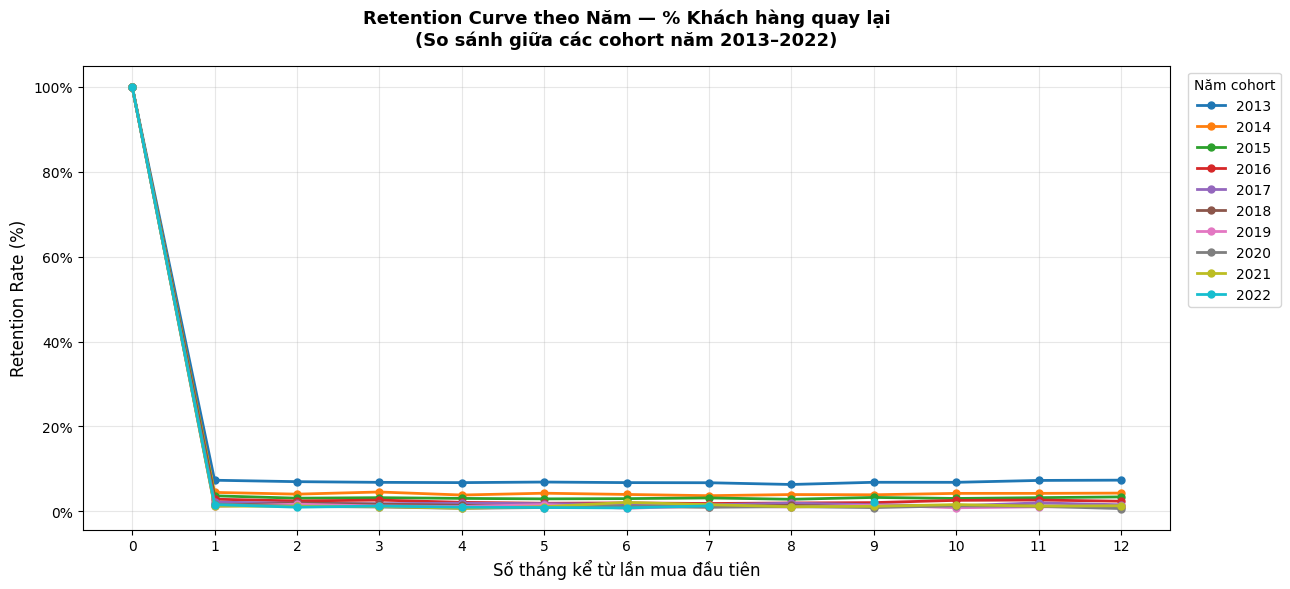

✅ Viz 7.2 saved
cohort_index      0         1         2         3         4         5  \
cohort_year                                                             
2013          100.0  7.320218  6.983254  6.823461  6.757447  6.895484   
2014          100.0  4.453815  4.044777  4.548727  3.836453  4.262982   
2015          100.0  3.647069  3.091852  3.211303  3.040094  2.927398   
2016          100.0  2.851833  2.438451  2.643974  2.115158  1.897891   
2017          100.0  2.170336  1.899808  1.785363  1.913328  1.808609   
2018          100.0  1.421054  1.930870  1.690352  1.411352  1.218290   
2019          100.0  1.178344  1.683215  1.240481  1.126169  1.586054   
2020          100.0  1.699222  1.158559  1.011060  0.705052  0.894743   
2021          100.0  1.217052  1.188480  1.126413  0.723885  1.097394   
2022          100.0  1.570210  0.968945  1.234187  0.975556  0.890087   

cohort_index         6         7         8         9        10        11  \
cohort_year                    

In [28]:
# ── Gộp cohort theo năm để so sánh ──
retention_pct_reset = retention_pct.reset_index()
retention_pct_reset["cohort_year"] = (
    retention_pct_reset["cohort_month"]
    .apply(lambda x: x.year)
)

# Tính trung bình retention theo năm
yearly_retention = retention_pct_reset.groupby(
    "cohort_year"
).mean(numeric_only=True).iloc[:, :13]

# Loại 2012 (không đủ data)
yearly_retention = yearly_retention[
    yearly_retention.index != 2012
]

# ── Vẽ retention curve ──
fig, ax = plt.subplots(figsize=(13, 6))

colors = plt.cm.tab10.colors
for i, (year, row) in enumerate(yearly_retention.iterrows()):
    ax.plot(
        row.index, row.values,
        marker="o", linewidth=2, markersize=5,
        label=str(year), color=colors[i % len(colors)]
    )

ax.set_title(
    "Retention Curve theo Năm — % Khách hàng quay lại\n"
    "(So sánh giữa các cohort năm 2013–2022)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Số tháng kể từ lần mua đầu tiên",fontsize=12)
ax.set_ylabel("Retention Rate (%)",fontsize=12)
ax.set_xticks(range(13))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Năm cohort", bbox_to_anchor=(1.01, 1),
          loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("viz7_2_retention_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 7.2 saved")
print(yearly_retention)

**3. Viz 3: Cohort Size — Số khách hàng mới mỗi tháng**

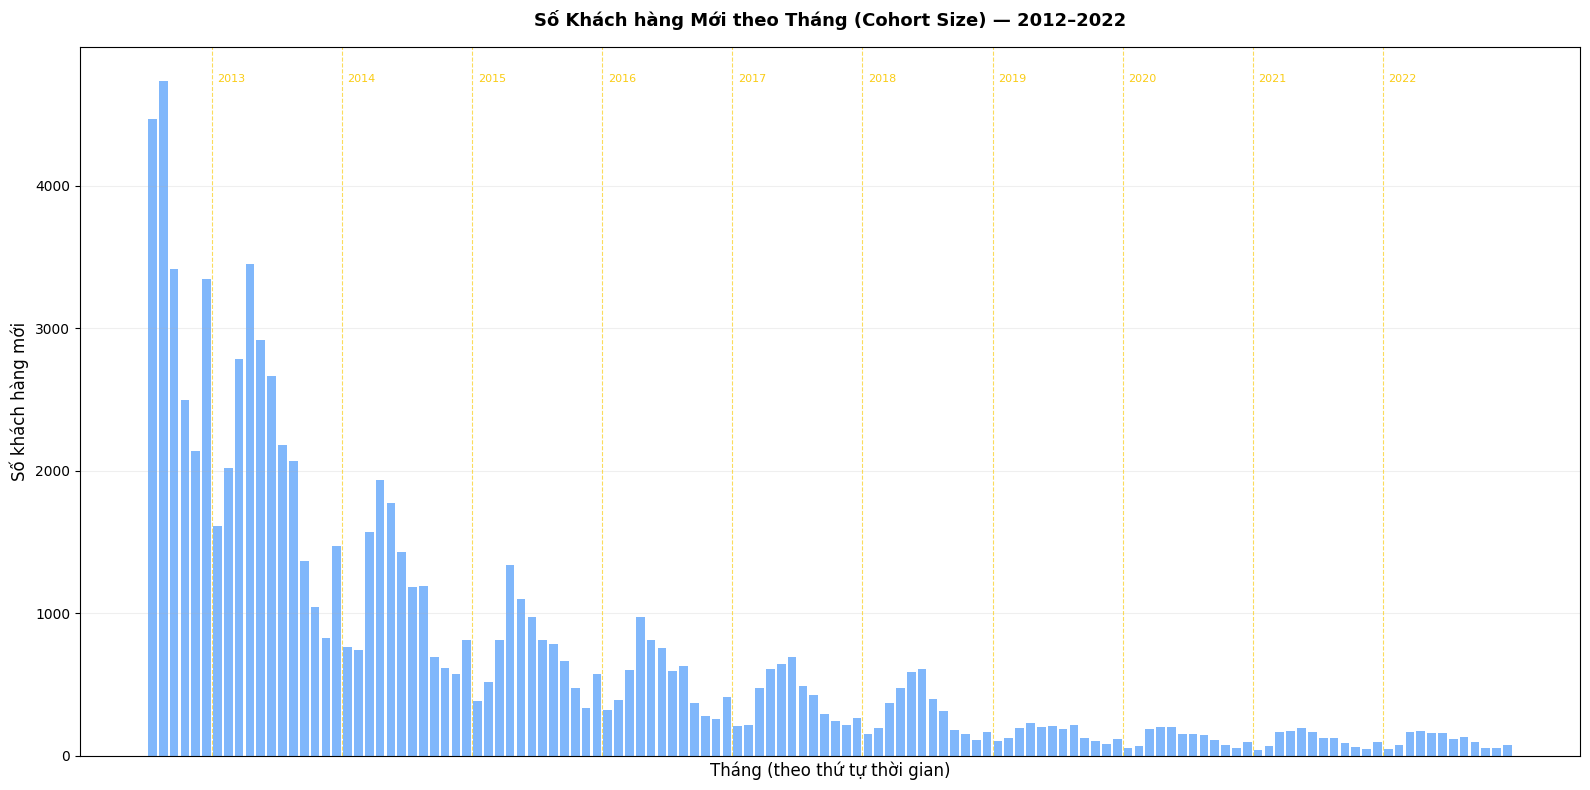

✅ Viz 7.3 saved


In [29]:
# ── Cohort size theo tháng ──
cohort_size_df = cohort_size.reset_index()
cohort_size_df.columns = ["cohort_month", "new_customers"]
cohort_size_df["year"]  = cohort_size_df["cohort_month"].apply(
    lambda x: x.year
)
cohort_size_df["month"] = cohort_size_df["cohort_month"].apply(
    lambda x: x.month
)

fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(
    range(len(cohort_size_df)),
    cohort_size_df["new_customers"],
    color="#60a5fa", alpha=0.8, width=0.8
)

# Đánh dấu ranh giới năm
year_starts = cohort_size_df[
    cohort_size_df["month"] == 1
].index.tolist()
for ys in year_starts:
    ax.axvline(x=ys - 0.5, color="#facc15",
               linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(ys, ax.get_ylim()[1] * 0.95,
            str(cohort_size_df.loc[ys, "year"]),
            color="#facc15", fontsize=8, ha="left")

ax.set_title(
    "Số Khách hàng Mới theo Tháng (Cohort Size) — 2012–2022",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Tháng (theo thứ tự thời gian)",fontsize=12)
ax.set_ylabel("Số khách hàng mới",fontsize=12)
ax.set_xticks([])
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("viz7_3_cohort_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 7.3 saved")

**4. Viz 4: ARPU theo Cohort Year**

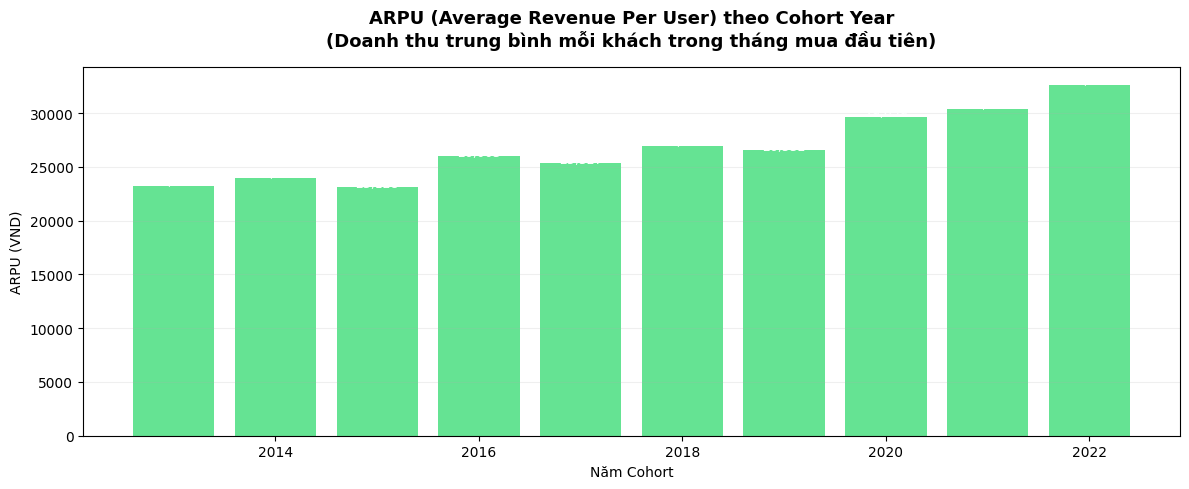

✅ Viz 7.4 saved


In [30]:
# ── Tính ARPU: Revenue trung bình mỗi khách theo cohort ──
order_items = dfs["order_items"].copy()
order_items["line_revenue"] = (
    order_items["unit_price"] * order_items["quantity"]
)

order_revenue = order_items.groupby("order_id")[
    "line_revenue"
].sum().reset_index()
order_revenue.columns = ["order_id", "order_revenue"]

# Join với cohort data
orders_arpu = orders_valid.merge(
    order_revenue, on="order_id", how="left"
)

arpu_by_cohort = orders_arpu.groupby(
    ["cohort_month", "cohort_index"]
).agg(
    total_revenue=("order_revenue", "sum"),
    unique_customers=("customer_id", "nunique")
).reset_index()

arpu_by_cohort["arpu"] = (
    arpu_by_cohort["total_revenue"] /
    arpu_by_cohort["unique_customers"]
)

# Gộp theo năm
arpu_by_cohort["cohort_year"] = arpu_by_cohort[
    "cohort_month"
].apply(lambda x: x.year)

arpu_yearly = arpu_by_cohort[
    arpu_by_cohort["cohort_index"] == 0
].groupby("cohort_year")["arpu"].mean()

arpu_yearly = arpu_yearly[arpu_yearly.index != 2012]

# ── Vẽ ARPU ──
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    arpu_yearly.index, arpu_yearly.values,
    color="#4ade80", alpha=0.85
)

for year, val in arpu_yearly.items():
    ax.text(year, val + 50, f"{val:,.0f}",
            ha="center", fontsize=9, color="white")

ax.set_title(
    "ARPU (Average Revenue Per User) theo Cohort Year\n"
    "(Doanh thu trung bình mỗi khách trong tháng mua đầu tiên)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Năm Cohort")
ax.set_ylabel("ARPU (VND)")
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("viz7_4_arpu.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 7.4 saved")

**TÍNH CÁC SỐ LIỆU CẦN THIẾT CHO VIỆC PHÂN TÍCH**

**1. PHÂN TÍCH DESCRIPTIVE**

In [31]:
# ── Angle 7: Tính số liệu phân tích 4 cấp độ ──

print("=" * 60)
print("DESCRIPTIVE — Thống kê Retention tổng hợp")
print("=" * 60)

# Retention rate trung bình tại các mốc quan trọng
for idx in [1, 3, 6, 12]:
    if idx in retention_pct.columns:
        avg = retention_pct[idx].dropna().mean()
        print(f"   Retention tháng {idx:>2d}: {avg:.1f}%")

# Drop rate mạnh nhất ở đâu?
avg_retention = retention_pct.mean(numeric_only=True).iloc[:13]
drops = avg_retention.diff().dropna()
worst_drop_idx = drops.idxmin()
worst_drop_val = drops.min()
print(f"\n📌 Drop mạnh nhất: từ tháng "
      f"{worst_drop_idx-1} → tháng {worst_drop_idx} "
      f"({worst_drop_val:.1f}%)")

print(f"\n📌 Tổng khách hàng (cohort size tháng 0): "
      f"{cohort_size.sum():,}")
print(f"📌 Cohort size trung bình mỗi tháng: "
      f"{cohort_size.mean():,.0f} khách")
print(f"📌 Cohort size cao nhất: "
      f"{cohort_size.max():,.0f} khách "
      f"({cohort_size.idxmax()})")
print(f"📌 Cohort size thấp nhất (bỏ qua 2012): "
      f"{cohort_size[cohort_size.index > '2012-12'].min():,.0f} khách")

DESCRIPTIVE — Thống kê Retention tổng hợp
   Retention tháng  1: 3.3%
   Retention tháng  3: 3.1%
   Retention tháng  6: 3.2%
   Retention tháng 12: 3.3%

📌 Drop mạnh nhất: từ tháng 0 → tháng 1 (-96.7%)

📌 Tổng khách hàng (cohort size tháng 0): 88,123.0
📌 Cohort size trung bình mỗi tháng: 699 khách
📌 Cohort size cao nhất: 4,736 khách (2012-08)
📌 Cohort size thấp nhất (bỏ qua 2012): 40 khách


**2. PHÂN TÍCH DIAGNOSTIC**

In [32]:
print("\n" + "=" * 60)
print("DIAGNOSTIC — So sánh retention theo giai đoạn")
print("=" * 60)

# So sánh retention tháng 1 theo từng năm
print("\n📊 Retention Rate tháng 1 theo năm cohort:")
for year, row in yearly_retention.iterrows():
    if 1 in row.index:
        print(f"   {year}: {row[1]:.1f}%")

# Giai đoạn tăng trưởng vs suy giảm cohort size
cohort_size_df["cohort_month_str"] = cohort_size_df[
    "cohort_month"].astype(str)

# So sánh cohort size 2013-2016 vs 2019-2022
early = cohort_size_df[
    cohort_size_df["year"].isin([2013,2014,2015,2016])
]["new_customers"].mean()
late = cohort_size_df[
    cohort_size_df["year"].isin([2019,2020,2021,2022])
]["new_customers"].mean()
decline_pct = (late - early) / early * 100

print(f"\n📌 Cohort size TB giai đoạn 2013-2016: {early:,.0f} khách/tháng")
print(f"📌 Cohort size TB giai đoạn 2019-2022: {late:,.0f} khách/tháng")
print(f"📌 Mức sụt giảm: {decline_pct:.1f}%")


DIAGNOSTIC — So sánh retention theo giai đoạn

📊 Retention Rate tháng 1 theo năm cohort:
   2013: 7.3%
   2014: 4.5%
   2015: 3.6%
   2016: 2.9%
   2017: 2.2%
   2018: 1.4%
   2019: 1.2%
   2020: 1.7%
   2021: 1.2%
   2022: 1.6%

📌 Cohort size TB giai đoạn 2013-2016: 1,102 khách/tháng
📌 Cohort size TB giai đoạn 2019-2022: 128 khách/tháng
📌 Mức sụt giảm: -88.4%


**3. PHÂN TÍCH PREDICTIVE**

In [33]:
print("\n" + "=" * 60)
print("PREDICTIVE — Dự báo retention")
print("=" * 60)

# Retention tháng 1 của các cohort gần nhất (2020-2022)
recent_years = [2020, 2021, 2022]
recent_r1 = yearly_retention[
    yearly_retention.index.isin(recent_years)
][1].mean() if 1 in yearly_retention.columns else None

print(f"\n📌 Retention tháng 1 trung bình 2020-2022: "
      f"{recent_r1:.1f}%")
print(f"📌 Nếu không can thiệp, dự báo retention tháng 1/2023: "
      f"~{recent_r1:.1f}% (tiếp tục xu hướng hiện tại)")

# Tính số khách bị mất ở tháng 1
avg_cohort_size_recent = cohort_size_df[
    cohort_size_df["year"].isin(recent_years)
]["new_customers"].mean()
customers_lost_m1 = avg_cohort_size_recent * (1 - recent_r1/100)
print(f"\n📌 Với cohort size TB {avg_cohort_size_recent:,.0f} khách/tháng:")
print(f"   → Mất khoảng {customers_lost_m1:,.0f} khách ngay tháng 1 "
      f"({100-recent_r1:.1f}%)")

# ARPU để tính revenue bị mất
arpu_recent = arpu_yearly[
    arpu_yearly.index.isin(recent_years)
].mean()
revenue_lost_m1 = customers_lost_m1 * arpu_recent
print(f"   → Doanh thu tiềm năng bị mất: "
      f"{revenue_lost_m1:,.0f} VND/tháng")


PREDICTIVE — Dự báo retention

📌 Retention tháng 1 trung bình 2020-2022: 1.5%
📌 Nếu không can thiệp, dự báo retention tháng 1/2023: ~1.5% (tiếp tục xu hướng hiện tại)

📌 Với cohort size TB 117 khách/tháng:
   → Mất khoảng 116 khách ngay tháng 1 (98.5%)
   → Doanh thu tiềm năng bị mất: 3,575,885 VND/tháng


**4. PHÂN TÍCH PRESCRIPTIVE**

In [34]:
print("\n" + "=" * 60)
print("PRESCRIPTIVE — Cơ sở đề xuất từ data")
print("=" * 60)

# Nếu tăng retention tháng 1 lên X% thì được gì?
print(f"\n📊 TIỀM NĂNG NẾU CẢI THIỆN RETENTION THÁNG 1:")
current_r1 = recent_r1
for target in [5, 8, 10]:
    if target > current_r1:
        extra_customers = avg_cohort_size_recent * \
                         (target - current_r1) / 100
        extra_revenue   = extra_customers * arpu_recent
        print(f"   Nếu retention T1 tăng từ {current_r1:.1f}% → {target}%:")
        print(f"   → Giữ thêm {extra_customers:,.0f} khách/tháng")
        print(f"   → Doanh thu tăng thêm {extra_revenue:,.0f} VND/tháng")
        print()

# Mâu thuẫn thú vị: ARPU 2022 cao nhất nhưng retention thấp nhất
arpu_2013 = arpu_yearly.get(2013, None)
arpu_2022 = arpu_yearly.get(2022, None)
if arpu_2013 and arpu_2022:
    arpu_growth = (arpu_2022 - arpu_2013) / arpu_2013 * 100
    print(f"📌 ARPU 2013: {arpu_2013:,.0f} VND")
    print(f"📌 ARPU 2022: {arpu_2022:,.0f} VND "
          f"(+{arpu_growth:.1f}% so với 2013)")
    print(f"   → Khách hàng chi tiêu NHIỀU HƠN nhưng quay lại ÍT HƠN")
    print(f"   → Đây là dấu hiệu của 'high-value one-time buyers'")


PRESCRIPTIVE — Cơ sở đề xuất từ data

📊 TIỀM NĂNG NẾU CẢI THIỆN RETENTION THÁNG 1:
   Nếu retention T1 tăng từ 1.5% → 5%:
   → Giữ thêm 4 khách/tháng
   → Doanh thu tăng thêm 127,220 VND/tháng

   Nếu retention T1 tăng từ 1.5% → 8%:
   → Giữ thêm 8 khách/tháng
   → Doanh thu tăng thêm 236,125 VND/tháng

   Nếu retention T1 tăng từ 1.5% → 10%:
   → Giữ thêm 10 khách/tháng
   → Doanh thu tăng thêm 308,728 VND/tháng

📌 ARPU 2013: 23,230 VND
📌 ARPU 2022: 32,663 VND (+40.6% so với 2013)
   → Khách hàng chi tiêu NHIỀU HƠN nhưng quay lại ÍT HƠN
   → Đây là dấu hiệu của 'high-value one-time buyers'
